# Week 6 - predicting the person and the group from the mail body

Last week split the 149 mailbox owners into three behavioural groups by *how*
they use mail (a broadcaster/executive corner, an outward-facing dealmaker
corner, and a large internal majority), and showed that a quick content view of
*what* they write overlaps heavily across those groups. This week turns that into
a supervised question, on the body text only:

* **Group prediction** - given a cleaned message body, can a model say which of
  the three behavioural groups its author belongs to?
* **Person identification** - given the same body, can it say *who* wrote it?

We try three text representations (a sparse TF-IDF vector, a dense semantic
embedding, and character n-grams that pick up writing style) and, critically,
score the group task on held-out *people* so a model cannot win by memorising
individual authors. The two questions come apart sharply, which is the result.

Everything runs on the cleaned, deduplicated dataset under `eda-5/clean/`, with
each message resolved to its author through the `sender_person` column.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score
from scipy.cluster.hierarchy import linkage, fcluster

import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE = "#7a5ea6"

pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white", colorway=[BLUE, ORANGE, GREEN, RED],
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14)),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14)),
    legend=dict(font=dict(size=15)),
))
pio.templates.default = "enron"

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-5" / "clean" / "messages_clean.parquet").exists():
            return base
    raise FileNotFoundError("eda-5/clean not found above " + str(here))

ROOT = find_root()
PLOTS = ROOT / "pred-1" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)
CLEAN = ROOT / "eda-5" / "clean"

def save_fig(fig, name, w=1100, h=560, margin=None):
    # scale=2 keeps the exported PNG legible without the 2k+ px overflow the wiki
    # had with scale=3; the report also caps width with a max-width:100% style.
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=2)
    im = _PILImage.open(out); im.save(out, dpi=(200, 200))
    _show(_PNG(filename=str(out)))
    return fig

def disp(handle):
    "kaminski-v -> 'Kaminski V'"
    sn, _, ini = handle.partition("-")
    return f"{sn.replace('.', ' ').title()} {ini.upper()}".strip()

msg = pd.read_parquet(CLEAN / "messages_clean.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet")
people = pd.read_parquet(CLEAN / "people.parquet")
roles = pd.read_parquet(CLEAN / "people_roles.parquet")
print(f"unique messages: {len(msg):,}   resolved to an author: "
      f"{msg['sender_person'].notna().sum():,} ({msg['sender_person'].notna().mean():.0%})")

unique messages: 252,022   resolved to an author: 107,670 (43%)


## The three behavioural groups, recovered

The groups are the same ones from last week, rebuilt here so the notebook stands
on its own: twelve behavioural features per owner (volume, reach, external share,
broadcast share, thread-opening, weekend share, tenure, mailbox deletion rate,
and in/out degree on the internal people-graph), log-scaled where they span
orders of magnitude, standardised, then cut into three groups with Ward's method.
The cut reproduces a small **Broadcasters / execs** corner, an **Outward-facing**
group, and the large **Internal majority**. These three labels are the target of
the group-prediction task; nothing about the message text goes into building them.

In [2]:
MIN_AUTHORED = 30
authored = msg[msg["sender_person"].notna()].copy()
ac = authored.groupby("sender_person").size()
keep = sorted(ac[ac >= MIN_AUTHORED].index)

a = authored[authored["date_plausible"] & authored["date"].notna()].copy()
a["wknd"] = a["date"].dt.dayofweek >= 5
g, ag = authored.groupby("sender_person"), a.groupby("sender_person")

F = pd.DataFrame(index=keep)
F["n_sent"]        = g.size()
F["med_len"]       = g["body_chars"].median()
F["mean_recip"]    = g["recipient_count"].mean()
F["ext_ratio"]     = g["has_external_recipient"].mean()
F["cc_ratio"]      = g["cc_count"].sum() / g["recipient_count"].sum().replace(0, np.nan)
F["broadcast"]     = authored.assign(b=authored["recipient_count"] > 5).groupby("sender_person")["b"].mean()
F["root_ratio"]    = g["is_thread_root"].mean()
F["wknd_ratio"]    = ag["wknd"].mean()
F["active_months"] = (ag["date"].max() - ag["date"].min()).dt.days / 30.44
F["del_rate"]      = msg.assign(d=msg["folder_group"].eq("deleted")).groupby("mailbox_owner")["d"].mean().reindex(keep)

ei = rcp.merge(msg[["message_id", "sender_person"]], on="message_id")
ei = ei[(ei["channel"] == "to") & ei["is_internal_recipient"] & ~ei["recipient_is_list"]
        & ~ei["is_self"] & ei["sender_person"].notna() & ei["recipient_person"].notna()
        & (ei["sender_person"] != ei["recipient_person"])]
F["out_deg"] = ei.groupby("sender_person")["recipient_person"].nunique().reindex(keep)
F["in_deg"]  = ei.groupby("recipient_person")["sender_person"].nunique().reindex(keep)
F = F.reindex(keep).fillna(F.median())

FEATS = list(F.columns)
for c in ["n_sent", "med_len", "mean_recip", "active_months", "out_deg", "in_deg"]:
    F[c] = np.log1p(F[c])
X = StandardScaler().fit_transform(F.values)

Z = linkage(X, method="ward")
clabel = fcluster(Z, 3, criterion="maxclust")
prof = pd.DataFrame(StandardScaler().fit_transform(F.values), columns=FEATS, index=keep)
prof["c"] = clabel
gm = prof.groupby("c").mean()
names, used = {}, set()
ex = gm["broadcast"].idxmax(); names[ex] = "Broadcasters / execs"; used.add(ex)
out = gm.loc[~gm.index.isin(used), "ext_ratio"].idxmax(); names[out] = "Outward-facing"; used.add(out)
names[[c for c in gm.index if c not in used][0]] = "Internal majority"
cl_name = {h: names[c] for h, c in zip(keep, clabel)}
GROUPS = ["Broadcasters / execs", "Outward-facing", "Internal majority"]
SHORT = {"Broadcasters / execs": "Broadcast", "Outward-facing": "Outward", "Internal majority": "Internal"}
CMAP = {"Broadcasters / execs": RED, "Outward-facing": ORANGE, "Internal majority": BLUE}
print({k: sum(v == k for v in cl_name.values()) for k in GROUPS})

{'Broadcasters / execs': 8, 'Outward-facing': 50, 'Internal majority': 85}


## One body corpus, three representations

We take every cleaned, non-boilerplate body from a profiled author and cap it at
150 messages per person so a few heavy senders do not dominate. From that one
corpus we build three views of the text:

* **TF-IDF words** - a sparse bag-of-words vector, the standard content baseline.
* **Dense embedding** - the same vocabulary compressed to 200 latent-semantic
  dimensions (truncated SVD over the TF-IDF matrix), a topic-level embedding of
  each message rather than its raw word counts.
* **Char 3-4-grams** - character sequences that capture spelling, sign-offs and
  punctuation habits, i.e. writing *style* independent of topic.

Three representations let us ask not just *whether* the body predicts a label but
*what kind* of signal carries it - topic words, compressed meaning, or style.

In [3]:
gp = authored[(authored["body_chars"] > 0) & (~authored["body_is_boilerplate"])
              & (~authored["body_empty_after_clean"]) & authored["sender_person"].isin(keep)].copy()
gp = gp.sample(frac=1, random_state=0)
gp["rk"] = gp.groupby("sender_person").cumcount()
gp = gp[gp["rk"] < 120]
texts = gp["body"].astype(str).tolist()
persons = np.asarray(gp["sender_person"].astype(str))
ygrp = np.asarray([cl_name[p] for p in persons], dtype=object)
print(f"corpus: {len(texts):,} bodies from {len(set(persons))} people")

word_vec = TfidfVectorizer(max_features=5000, stop_words="english", min_df=5, max_df=0.5,
                           token_pattern=r"[a-z][a-z]{2,}", sublinear_tf=True)
Xw = word_vec.fit_transform(texts)
Xe = normalize(TruncatedSVD(n_components=200, random_state=0).fit_transform(Xw))
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 4), min_df=5,
                           max_features=4000, sublinear_tf=True)
Xc = char_vec.fit_transform(texts)
REPS = {"TF-IDF words": Xw, "Dense embedding": Xe, "Char 3-4-grams": Xc}
print("shapes:", {k: v.shape for k, v in REPS.items()})

corpus: 15,587 bodies from 143 people


shapes: {'TF-IDF words': (15587, 5000), 'Dense embedding': (15587, 200), 'Char 3-4-grams': (15587, 4000)}


## Question 1: which behavioural group wrote this mail?

Here is the trap the evaluation has to avoid. If we split messages at random,
the same person lands in both the training and the test set, so a model can
recognise the *author* from their words and then look up which group that author
belongs to - scoring high without learning anything about the group itself. The
honest test holds out whole **people**: every author in the test fold is unseen
during training (a grouped 5-fold). The left panel shows both, for each
representation, against the majority baseline of always guessing the internal
group.

The gap is the finding. On a random split every representation looks strong; on
held-out people they all collapse to roughly the majority baseline. The right
panel shows why - the confusion matrix for the held-out word model pulls almost
everything into the internal majority, dissolving the two small groups. Topic
words, the dense embedding and character style all behave the same way: for a
person the model has never read before, the body does not reveal the behavioural
role. The group is a property of *who you write to and how widely*, and that
structure barely surfaces in the words themselves.

majority baseline: 0.643
random split:     {'TF-IDF words': 0.74, 'Dense embedding': 0.694, 'Char 3-4-grams': 0.728}
held-out people:  {'TF-IDF words': 0.589, 'Dense embedding': 0.592, 'Char 3-4-grams': 0.601}


/tmp/claude-1000/ipykernel_2602174/3481786117.py:52: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=2)


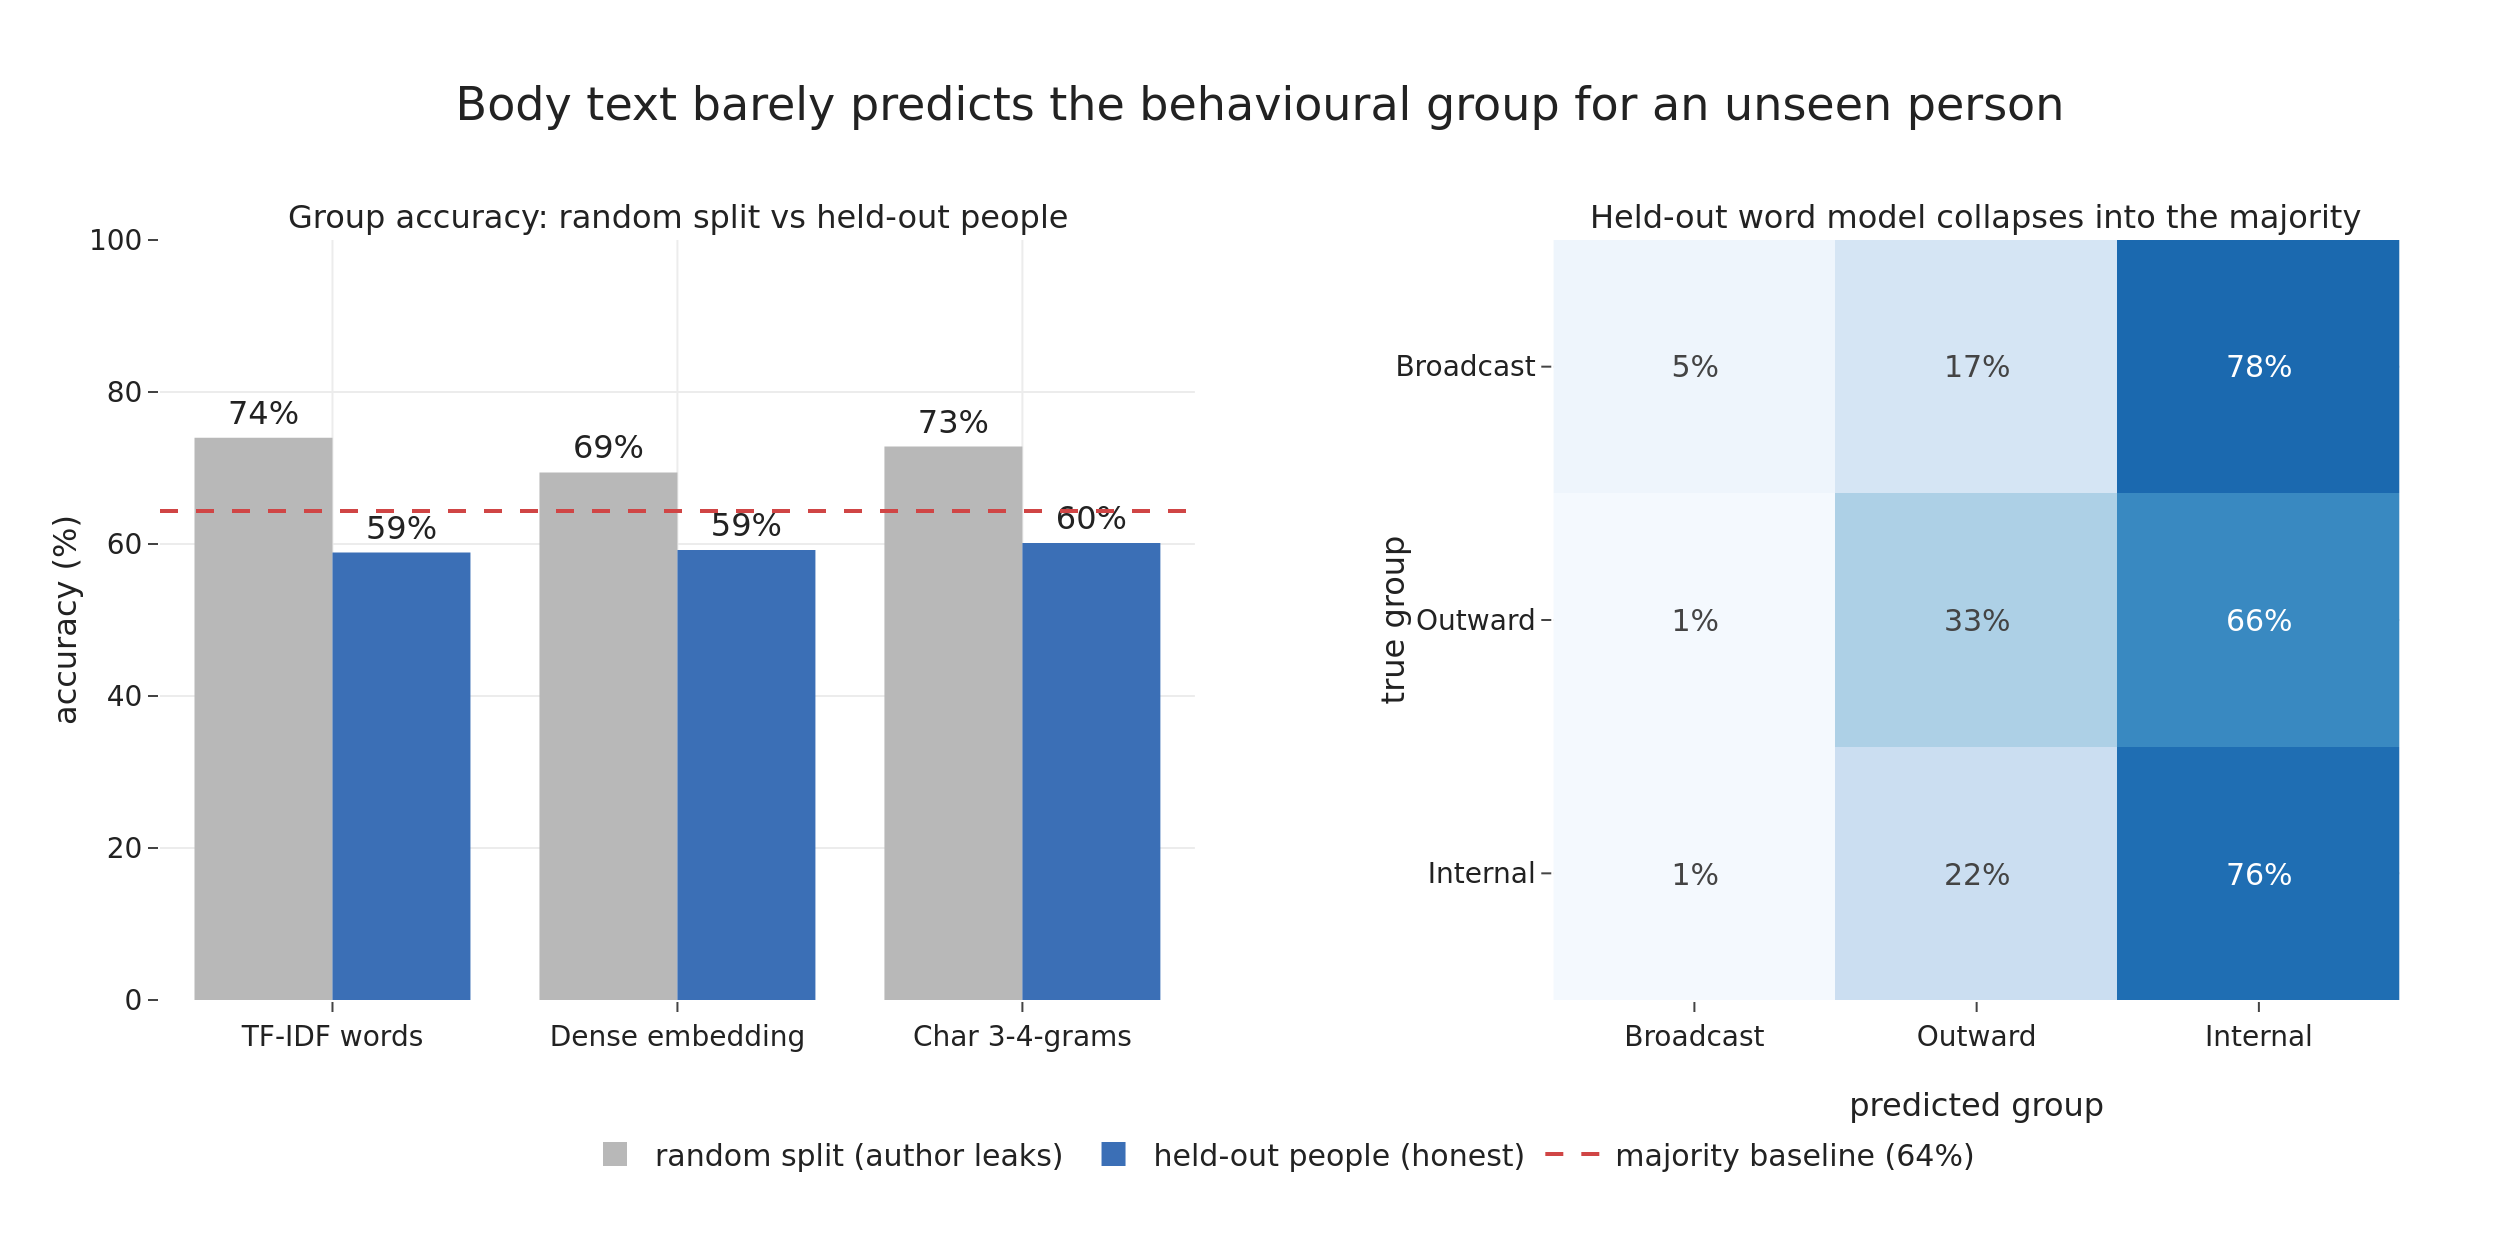

In [4]:
maj = pd.Series(ygrp).value_counts(normalize=True).max()
rand_acc, grp_acc = {}, {}
for name, Xr in REPS.items():
    pr_r = cross_val_predict(LinearSVC(C=1), Xr, ygrp, n_jobs=-1,
                             cv=StratifiedKFold(5, shuffle=True, random_state=0))
    pr_g = cross_val_predict(LinearSVC(C=1), Xr, ygrp, n_jobs=-1,
                             groups=persons, cv=GroupKFold(5))
    rand_acc[name] = accuracy_score(ygrp, pr_r)
    grp_acc[name] = accuracy_score(ygrp, pr_g)
    if name == "TF-IDF words":
        held_pred = pr_g
print("majority baseline:", round(maj, 3))
print("random split:    ", {k: round(v, 3) for k, v in rand_acc.items()})
print("held-out people: ", {k: round(v, 3) for k, v in grp_acc.items()})

cm = confusion_matrix(ygrp, held_pred, labels=GROUPS, normalize="true") * 100
fig = make_subplots(rows=1, cols=2, column_widths=[0.55, 0.45], horizontal_spacing=0.16,
    subplot_titles=["Group accuracy: random split vs held-out people",
                    "Held-out word model collapses into the majority"])
reps = list(REPS)
fig.add_trace(go.Bar(x=reps, y=[rand_acc[r] * 100 for r in reps], name="random split (author leaks)",
    marker_color=GREY, text=[f"{rand_acc[r]:.0%}" for r in reps], textposition="outside"), row=1, col=1)
fig.add_trace(go.Bar(x=reps, y=[grp_acc[r] * 100 for r in reps], name="held-out people (honest)",
    marker_color=BLUE, text=[f"{grp_acc[r]:.0%}" for r in reps], textposition="outside"), row=1, col=1)
fig.add_hline(y=maj * 100, line=dict(color=RED, dash="dash"), row=1, col=1)
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
    line=dict(color=RED, dash="dash", width=2),
    name=f"majority baseline ({maj:.0%})"), row=1, col=1)
fig.update_yaxes(title_text="accuracy (%)", range=[0, 100], row=1, col=1)
gl = [SHORT[g] for g in GROUPS]
fig.add_trace(go.Heatmap(z=cm, x=gl, y=gl, colorscale="Blues", zmin=0, zmax=100,
    text=np.round(cm).astype(int), texttemplate="%{text}%", showscale=False,
    textfont=dict(size=15)), row=1, col=2)
fig.update_xaxes(title_text="predicted group", row=1, col=2)
fig.update_yaxes(title_text="true group", autorange="reversed", row=1, col=2)
fig.update_layout(title="Body text barely predicts the behavioural group for an unseen person",
    barmode="group", legend=dict(orientation="h", y=-0.16, x=0.5, xanchor="center"))
save_fig(fig, "w6_1_group_prediction.png", w=1260, h=620,
         margin=dict(l=80, r=60, t=120, b=120))

## Question 2: who wrote this mail?

The same vectors answer the individual question completely differently. We take
the most active people, hold out a fifth of each one's messages, and ask the
model to name the author from the body. Here authors *are* supposed to appear in
both splits - that is the task - so a stratified fold is the right protocol. The
left panel tracks top-1 accuracy as the candidate pool grows from ten to fifty
people; the dashed line is random guessing.

People are highly recognisable from their own words. Among ten candidates the
TF-IDF model names the author about three quarters of the time, and even among
fifty it stays far above the one-in-fifty chance line. The dense embedding trails
the raw words slightly - compressing to 200 dimensions throws away rare,
person-specific terms - while character n-grams alone, pure style, already carry
much of the signal. The right panel ranks individuals by how identifiable they
are: topic specialists with a narrow beat sit at the top, generalists who write
short internal notes at the bottom. Recognisability is an individual trait, and
it is the same signal that fooled the random-split group score in question 1.

author-id top-1 accuracy: {'TF-IDF words': [0.74, 0.613, 0.599, 0.584], 'Dense embedding': [0.696, 0.55, 0.529, 0.508], 'Char 3-4-grams': [0.728, 0.632, 0.611, 0.597]}


/tmp/claude-1000/ipykernel_2602174/3481786117.py:52: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=2)


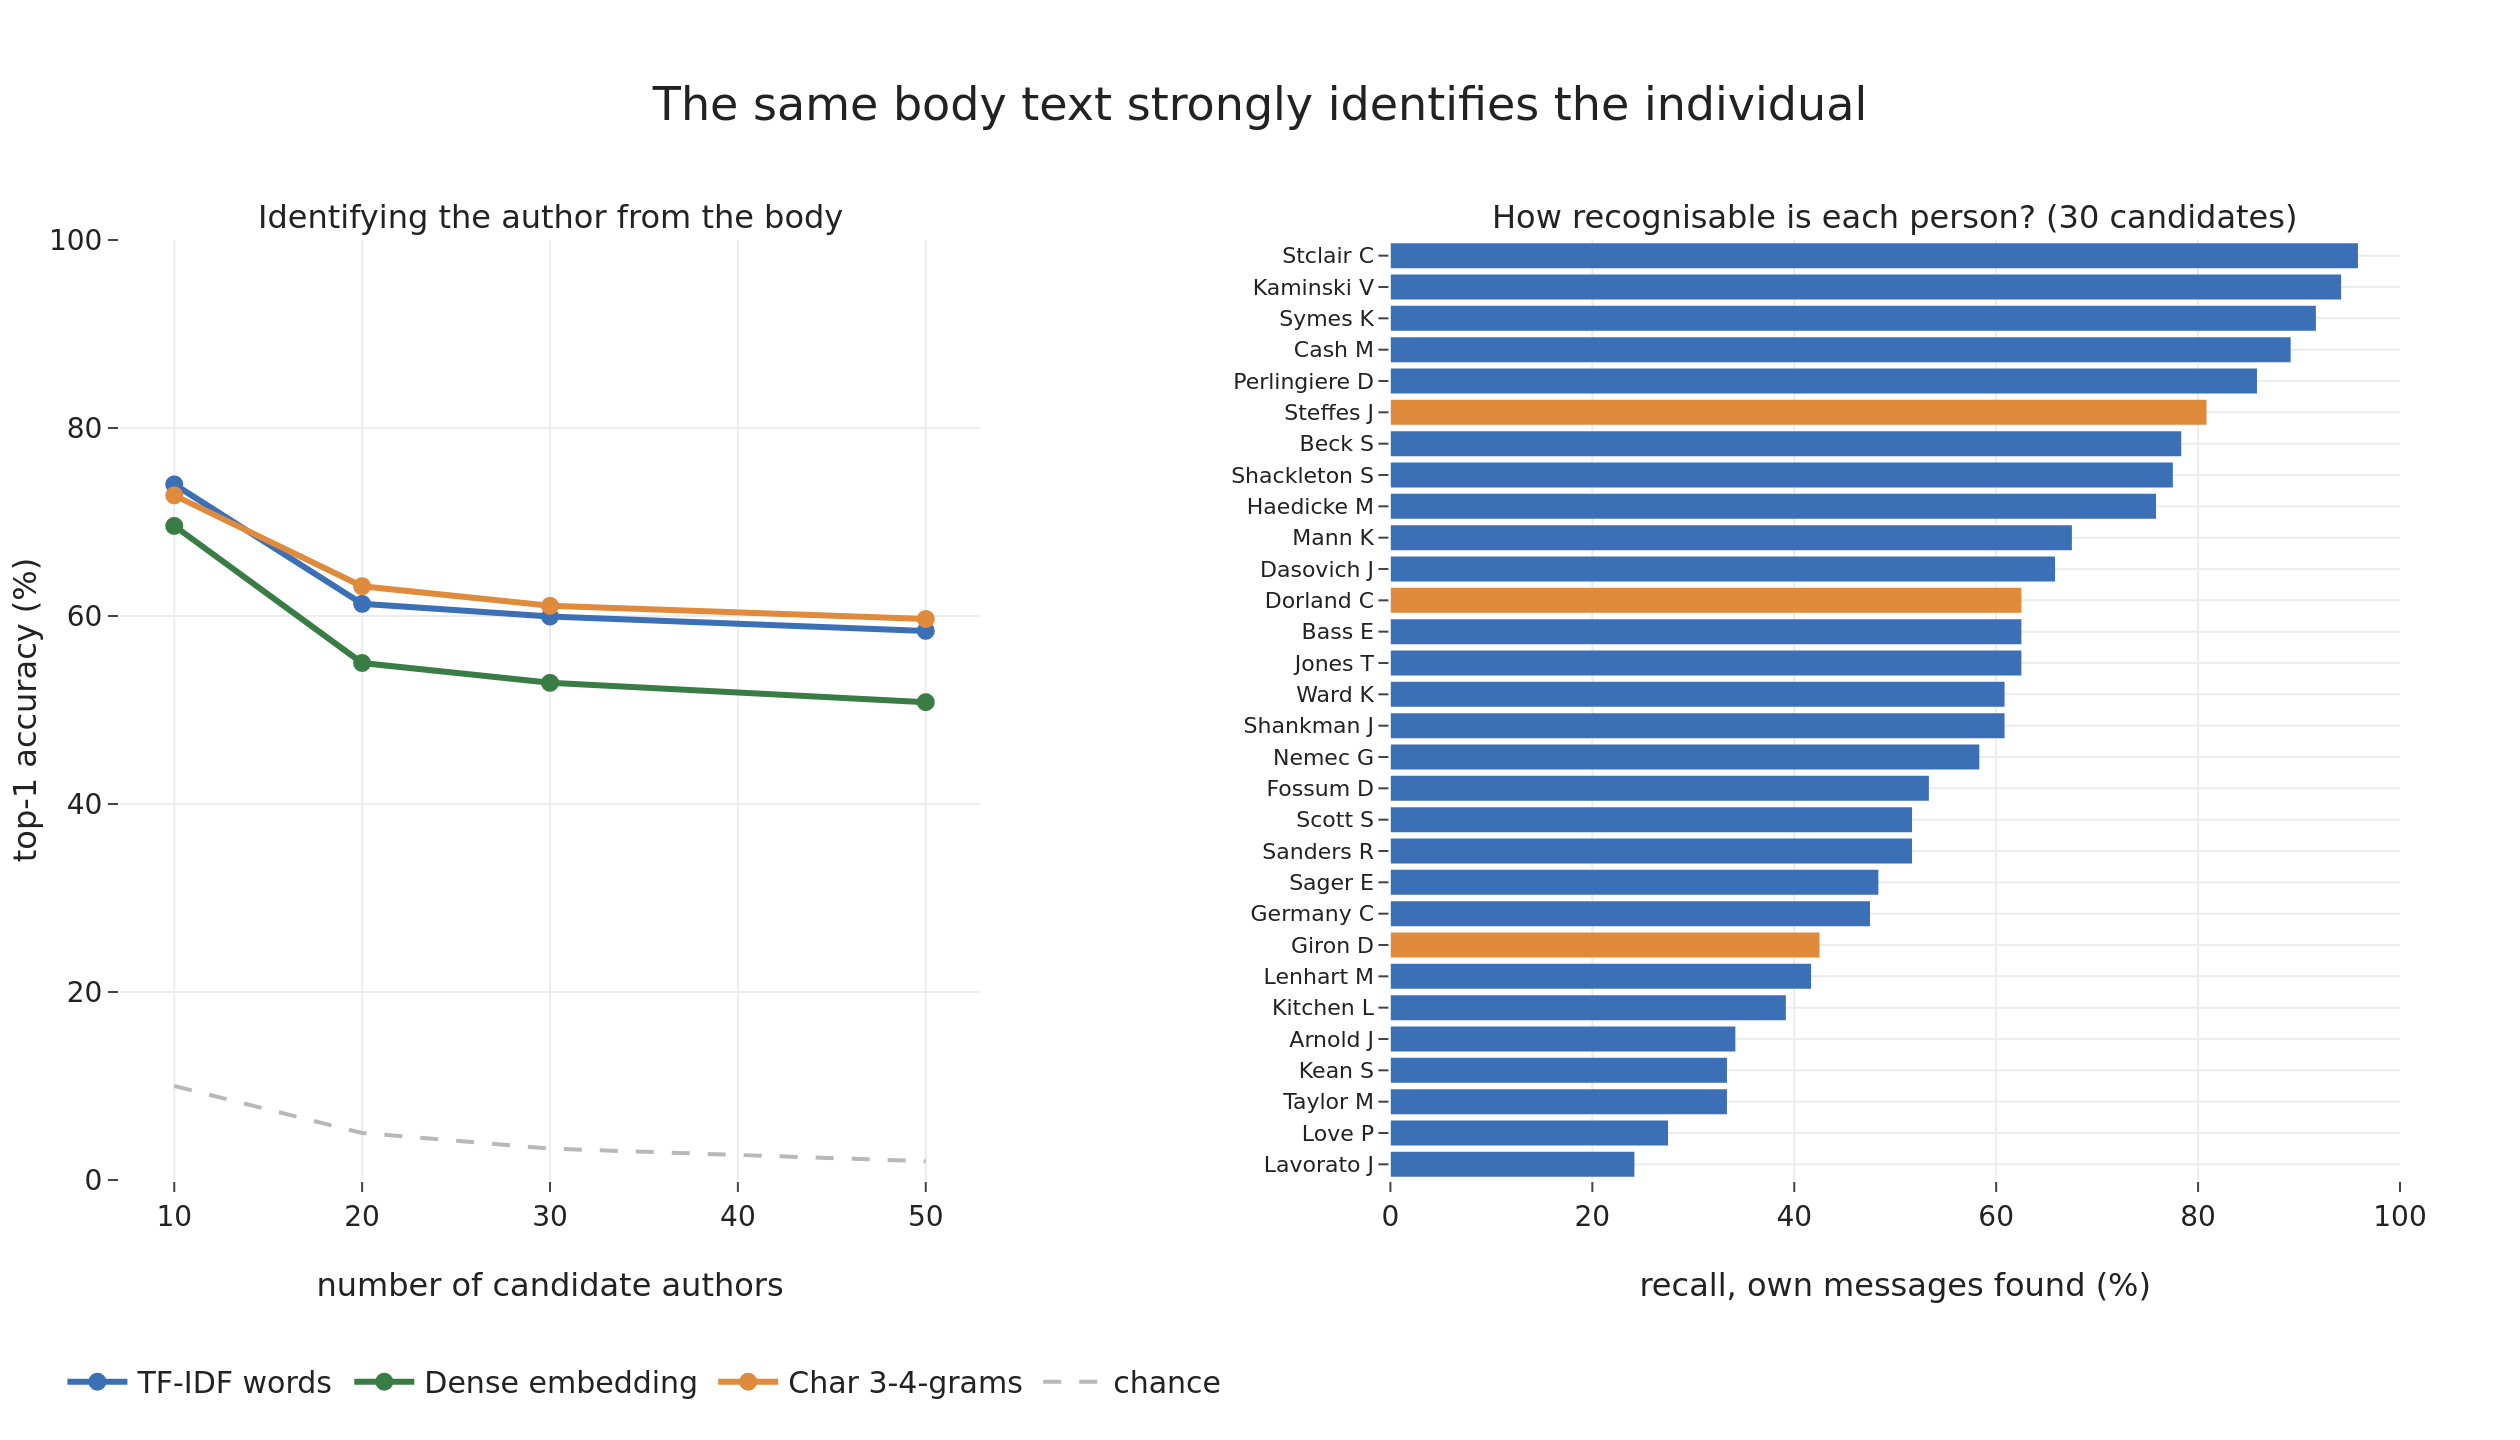

In [5]:
ordered = ac[list(keep)].sort_values(ascending=False).index.tolist()
Ns = [10, 20, 30, 50]
curves = {name: [] for name in REPS}
for N in Ns:
    m = np.isin(persons, ordered[:N])
    for name, Xr in REPS.items():
        pr = cross_val_predict(LinearSVC(C=1), Xr[m], persons[m], n_jobs=-1,
                               cv=StratifiedKFold(5, shuffle=True, random_state=0))
        curves[name].append(accuracy_score(persons[m], pr))
print("author-id top-1 accuracy:", {k: [round(x, 3) for x in v] for k, v in curves.items()})

# per-person identifiability at N=30, from the word model
m30 = np.isin(persons, ordered[:30])
pr30 = cross_val_predict(LinearSVC(C=1), Xw[m30], persons[m30], n_jobs=-1,
                         cv=StratifiedKFold(5, shuffle=True, random_state=0))
pp = persons[m30]
rec = {p: recall_score(pp == p, pr30 == p) for p in ordered[:30]}
rec = dict(sorted(rec.items(), key=lambda kv: kv[1]))

fig = make_subplots(rows=1, cols=2, column_widths=[0.46, 0.54], horizontal_spacing=0.18,
    subplot_titles=["Identifying the author from the body",
                    "How recognisable is each person? (30 candidates)"])
repcol = {"TF-IDF words": BLUE, "Dense embedding": GREEN, "Char 3-4-grams": ORANGE}
for name in REPS:
    fig.add_trace(go.Scatter(x=Ns, y=[v * 100 for v in curves[name]], mode="lines+markers",
        name=name, line=dict(width=3, color=repcol[name]), marker=dict(size=9)), row=1, col=1)
fig.add_trace(go.Scatter(x=Ns, y=[100 / N for N in Ns], mode="lines", name="chance",
    line=dict(color=GREY, dash="dash")), row=1, col=1)
fig.update_xaxes(title_text="number of candidate authors", dtick=10, row=1, col=1)
fig.update_yaxes(title_text="top-1 accuracy (%)", range=[0, 100], row=1, col=1)
hs = list(rec)
fig.add_trace(go.Bar(y=[disp(h) for h in hs], x=[rec[h] * 100 for h in hs], orientation="h",
    marker_color=[CMAP[cl_name[h]] for h in hs], showlegend=False), row=1, col=2)
fig.update_xaxes(title_text="recall, own messages found (%)", range=[0, 100], row=1, col=2)
fig.update_yaxes(tickfont=dict(size=11), row=1, col=2)
fig.update_layout(title="The same body text strongly identifies the individual",
    legend=dict(orientation="h", y=-0.18, x=0.23, xanchor="center"))
save_fig(fig, "w6_2_person_identification.png", w=1260, h=720,
         margin=dict(l=60, r=60, t=120, b=110))

## What the content space is organised by

If the body identifies the person but not their behavioural group, what *does* it
encode? Averaging each person's message embeddings into a single point and
projecting those points to two dimensions gives a map of the corpus by writing
content. Colour marks the behavioural group; the layout comes only from the text.

The behavioural colours do not form clean territories. The internal majority is
spread across the whole map and the handful of broadcasters sit among them; the
outward-facing group leans to one side but bleeds heavily into the middle rather
than separating. What organises the geometry is topical and structural: the
California-and-power names gather in one region, the trading and contracts desks
in others, regardless of behavioural group. That weak outward-facing lean is the
most the content carries, and it is exactly why the held-out classifier could
half-recover the outward group but fell below the majority baseline overall -
desk and subject matter cut across the behavioural roles instead of tracking them.

/tmp/claude-1000/ipykernel_2602174/3481786117.py:52: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=2)


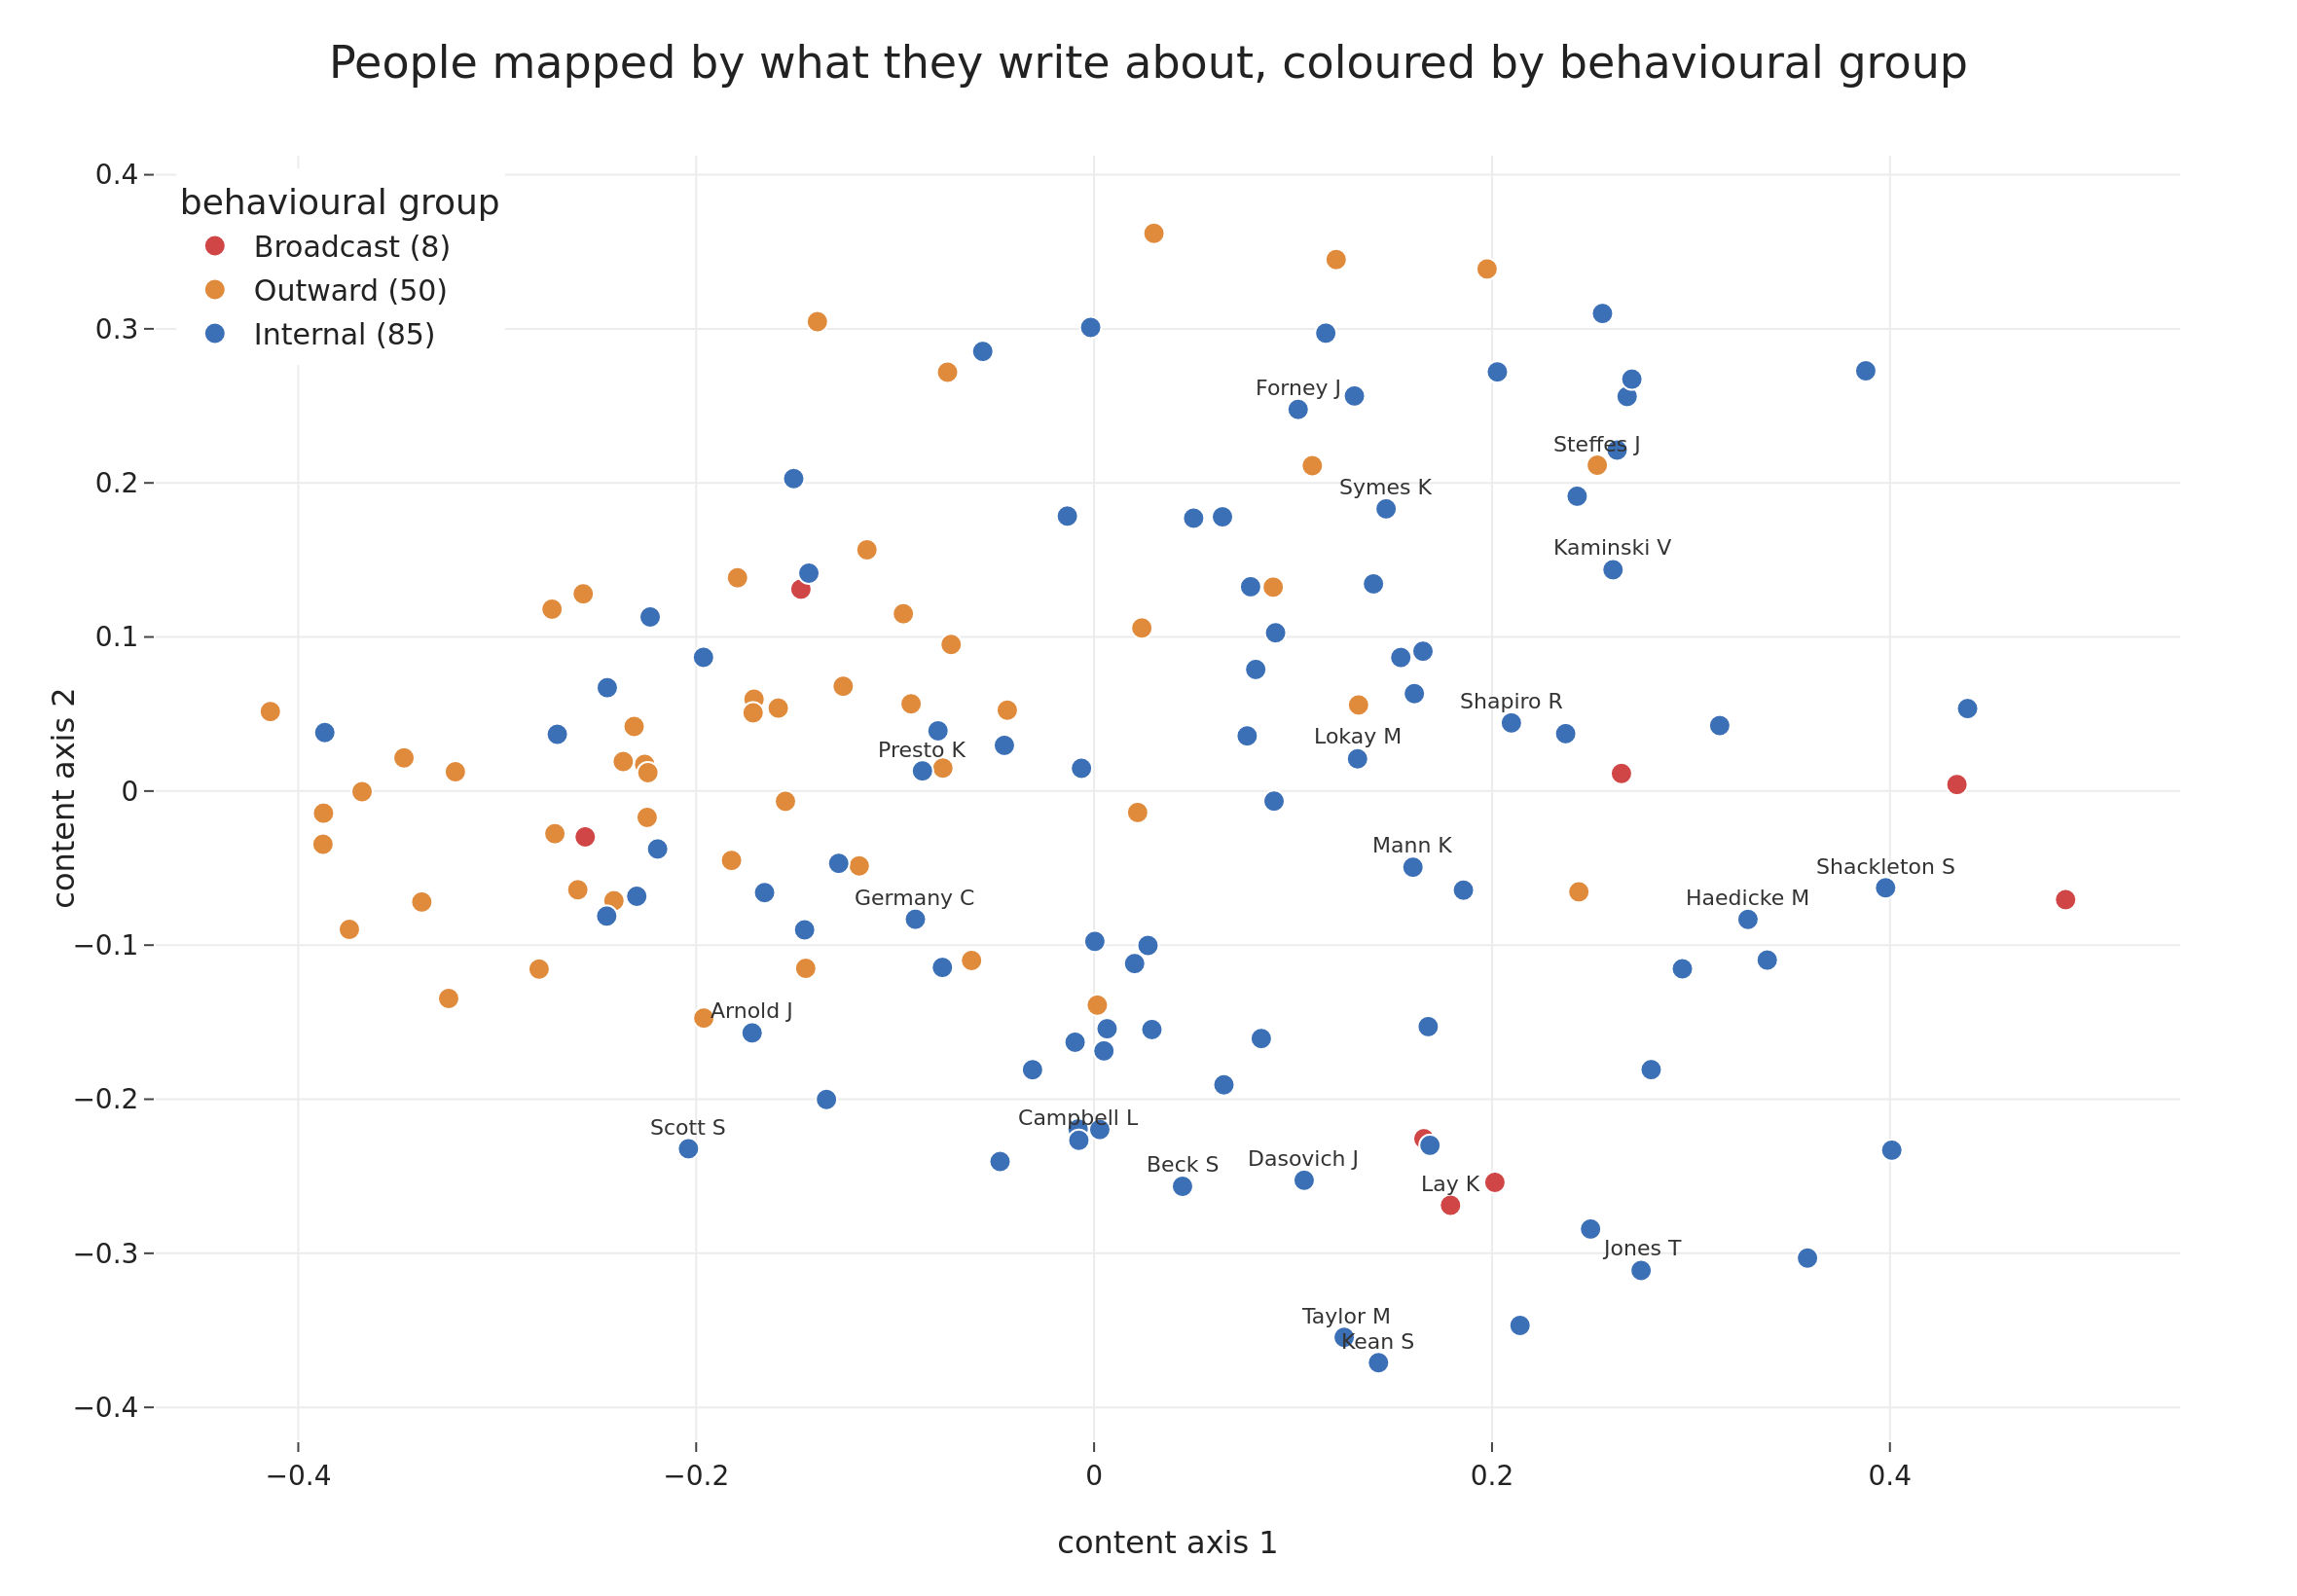

In [6]:
pe = pd.DataFrame(Xe, index=persons).groupby(level=0).mean()
pe = pe.loc[[p for p in ordered if p in pe.index]]
xy = PCA(n_components=2, random_state=0).fit_transform(normalize(pe.values))
pm = pd.DataFrame(xy, columns=["x", "y"], index=pe.index)

LABEL = [p for p in ["kaminski-v", "dasovich-j", "jones-t", "arnold-j", "forney-j",
         "lokay-m", "lay-k", "beck-s", "shackleton-s", "germany-c", "mann-k",
         "symes-k", "scott-s", "taylor-m", "shapiro-r", "steffes-j", "kean-s",
         "campbell-l", "haedicke-m", "presto-k"] if p in pm.index]
fig = go.Figure()
for grp in GROUPS:
    h = [p for p in pm.index if cl_name[p] == grp]
    fig.add_trace(go.Scatter(x=pm.loc[h, "x"], y=pm.loc[h, "y"], mode="markers",
        name=f"{SHORT[grp]} ({len(h)})", marker=dict(size=11, color=CMAP[grp],
        line=dict(width=1, color="white")),
        text=[disp(p) for p in h], hovertemplate="%{text}<extra></extra>"))
for p in LABEL:
    fig.add_annotation(x=pm.loc[p, "x"], y=pm.loc[p, "y"], text=disp(p),
        showarrow=False, yshift=11, font=dict(size=11, color="#333333"))
fig.update_layout(title="People mapped by what they write about, coloured by behavioural group",
    xaxis_title="content axis 1", yaxis_title="content axis 2",
    legend=dict(title="behavioural group", y=0.99, x=0.01))
save_fig(fig, "w6_3_content_map.png", w=1180, h=820, margin=dict(l=80, r=60, t=80, b=80))

## The individual fingerprints, word by word

Finally, the differences between individuals made concrete. For a set of
well-known people we take the words most over-represented in their own mail
against everyone else's - a weighted log-odds with a shrinkage prior so rare
words do not dominate - and drop each person's own name so the chart shows topic,
not signature. Every person resolves into a recognisable beat: Kaminski into
research and risk, Dasovich into California and electricity, Tana Jones into ISDA
masters and counterparties, John Arnold into NYMEX and volatility, Forney into
ERCOT and the real-time desk, Lokay into pipeline capacity and the Waha hub.
These narrow, stable vocabularies are exactly what made the individuals
identifiable two plots ago, and what a behavioural group label - built from reach
and broadcast, not subject matter - does not line up with.

/tmp/claude-1000/ipykernel_2602174/3481786117.py:52: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=2)


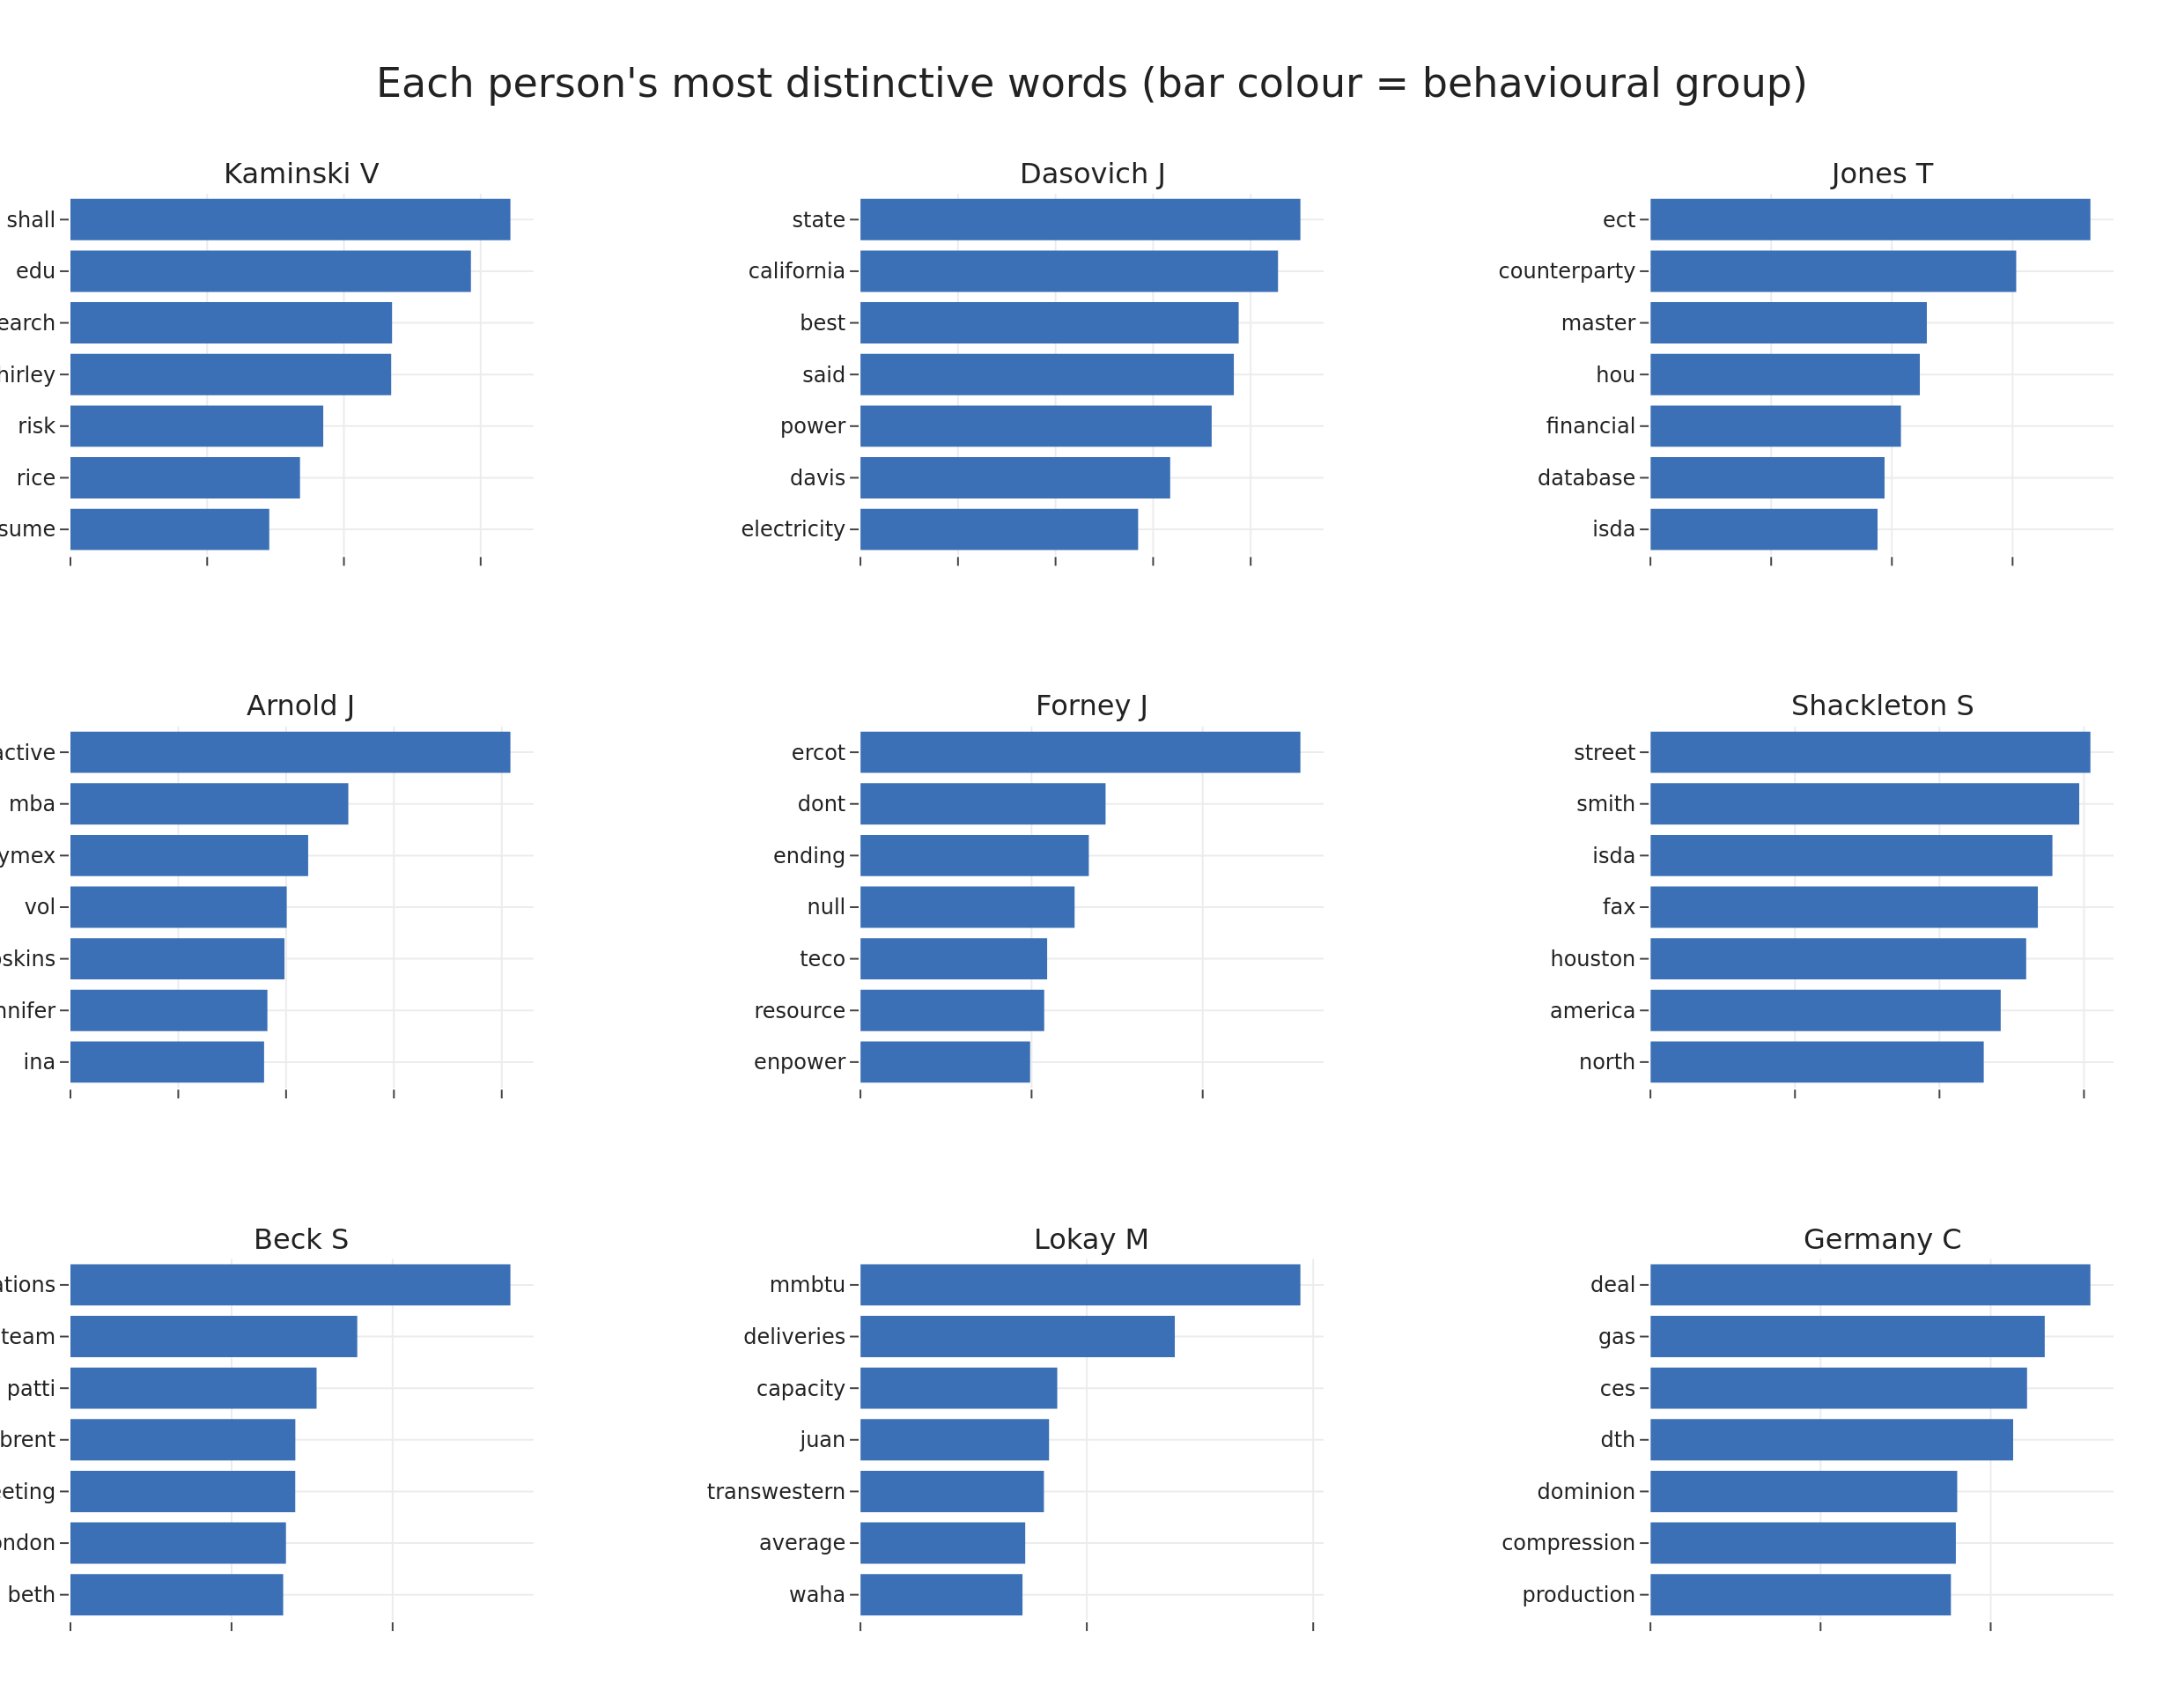

In [7]:
cv = CountVectorizer(max_features=4000, stop_words="english", min_df=8,
                     token_pattern=r"[a-z][a-z]{2,}")
pdocs = (authored[(authored["body_chars"] > 0) & (~authored["body_is_boilerplate"])
         & (~authored["body_empty_after_clean"]) & authored["sender_person"].isin(keep)]
         .groupby("sender_person")["body"].apply(lambda s: " ".join(s.astype(str))))
Cc = cv.fit_transform(pdocs.values)
vv = np.array(cv.get_feature_names_out())
tot = np.asarray(Cc.sum(0)).ravel(); Ntot = tot.sum(); A0 = 2000.0; aw = A0 * tot / Ntot
pidx = {p: i for i, p in enumerate(pdocs.index)}
NAMES = {r.owner: ({t for t in str(r.first_name).lower().split()}
                   | {t for t in str(r.last_name).lower().split()})
         for r in roles.itertuples()}

def distinct_words(p, k=7):
    yi = np.asarray(Cc[pidx[p]].todense()).ravel(); ni = yi.sum()
    yr = tot - yi; nr = Ntot - ni
    d = (np.log((yi + aw) / (ni + A0 - yi - aw)) - np.log((yr + aw) / (nr + A0 - yr - aw)))
    z = d / np.sqrt(1 / (yi + aw) + 1 / (yr + aw))
    own = set(disp(p).lower().split()) | {p.split("-")[0]} | NAMES.get(p, set())
    return [(vv[j], float(z[j])) for j in z.argsort()[::-1] if vv[j] not in own][:k][::-1]

PEOPLE = [p for p in ["kaminski-v", "dasovich-j", "jones-t", "arnold-j", "forney-j",
          "shackleton-s", "beck-s", "lokay-m", "germany-c"] if p in pidx]
ncol = 3; nrow = math.ceil(len(PEOPLE) / ncol)
fig = make_subplots(rows=nrow, cols=ncol, horizontal_spacing=0.16, vertical_spacing=0.12,
    subplot_titles=[disp(p) for p in PEOPLE])
for i, p in enumerate(PEOPLE):
    r, c = i // ncol + 1, i % ncol + 1
    ws = distinct_words(p, 7)
    fig.add_trace(go.Bar(y=[w for w, _ in ws], x=[zz for _, zz in ws], orientation="h",
        marker_color=CMAP[cl_name[p]], showlegend=False), row=r, col=c)
    fig.update_xaxes(showticklabels=False, row=r, col=c)
    fig.update_yaxes(tickfont=dict(size=12), row=r, col=c)
fig.update_layout(title="Each person's most distinctive words (bar colour = behavioural group)")
save_fig(fig, "w6_4_distinctive_words.png", w=1240, h=320 * nrow,
         margin=dict(l=40, r=40, t=110, b=40))

## Does behaviour close the gap?

The open question is whether the group becomes predictable once the body text is
joined with the behavioural features the groups were built from. We attach each
author's twelve-feature vector to every one of their messages and re-run the
held-out-people group prediction three ways: text alone, behaviour alone, and the
two together. The groups were defined by clustering those features, so behaviour
recovering them is partly built in; the informative comparison is whether text
adds anything on top of behaviour. It does not.

{'Body text (TF-IDF)': 0.589, 'Behaviour (12 features)': 0.868, 'Text + behaviour': 0.882} | majority 0.643


/tmp/claude-1000/ipykernel_2602174/3481786117.py:52: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=2)


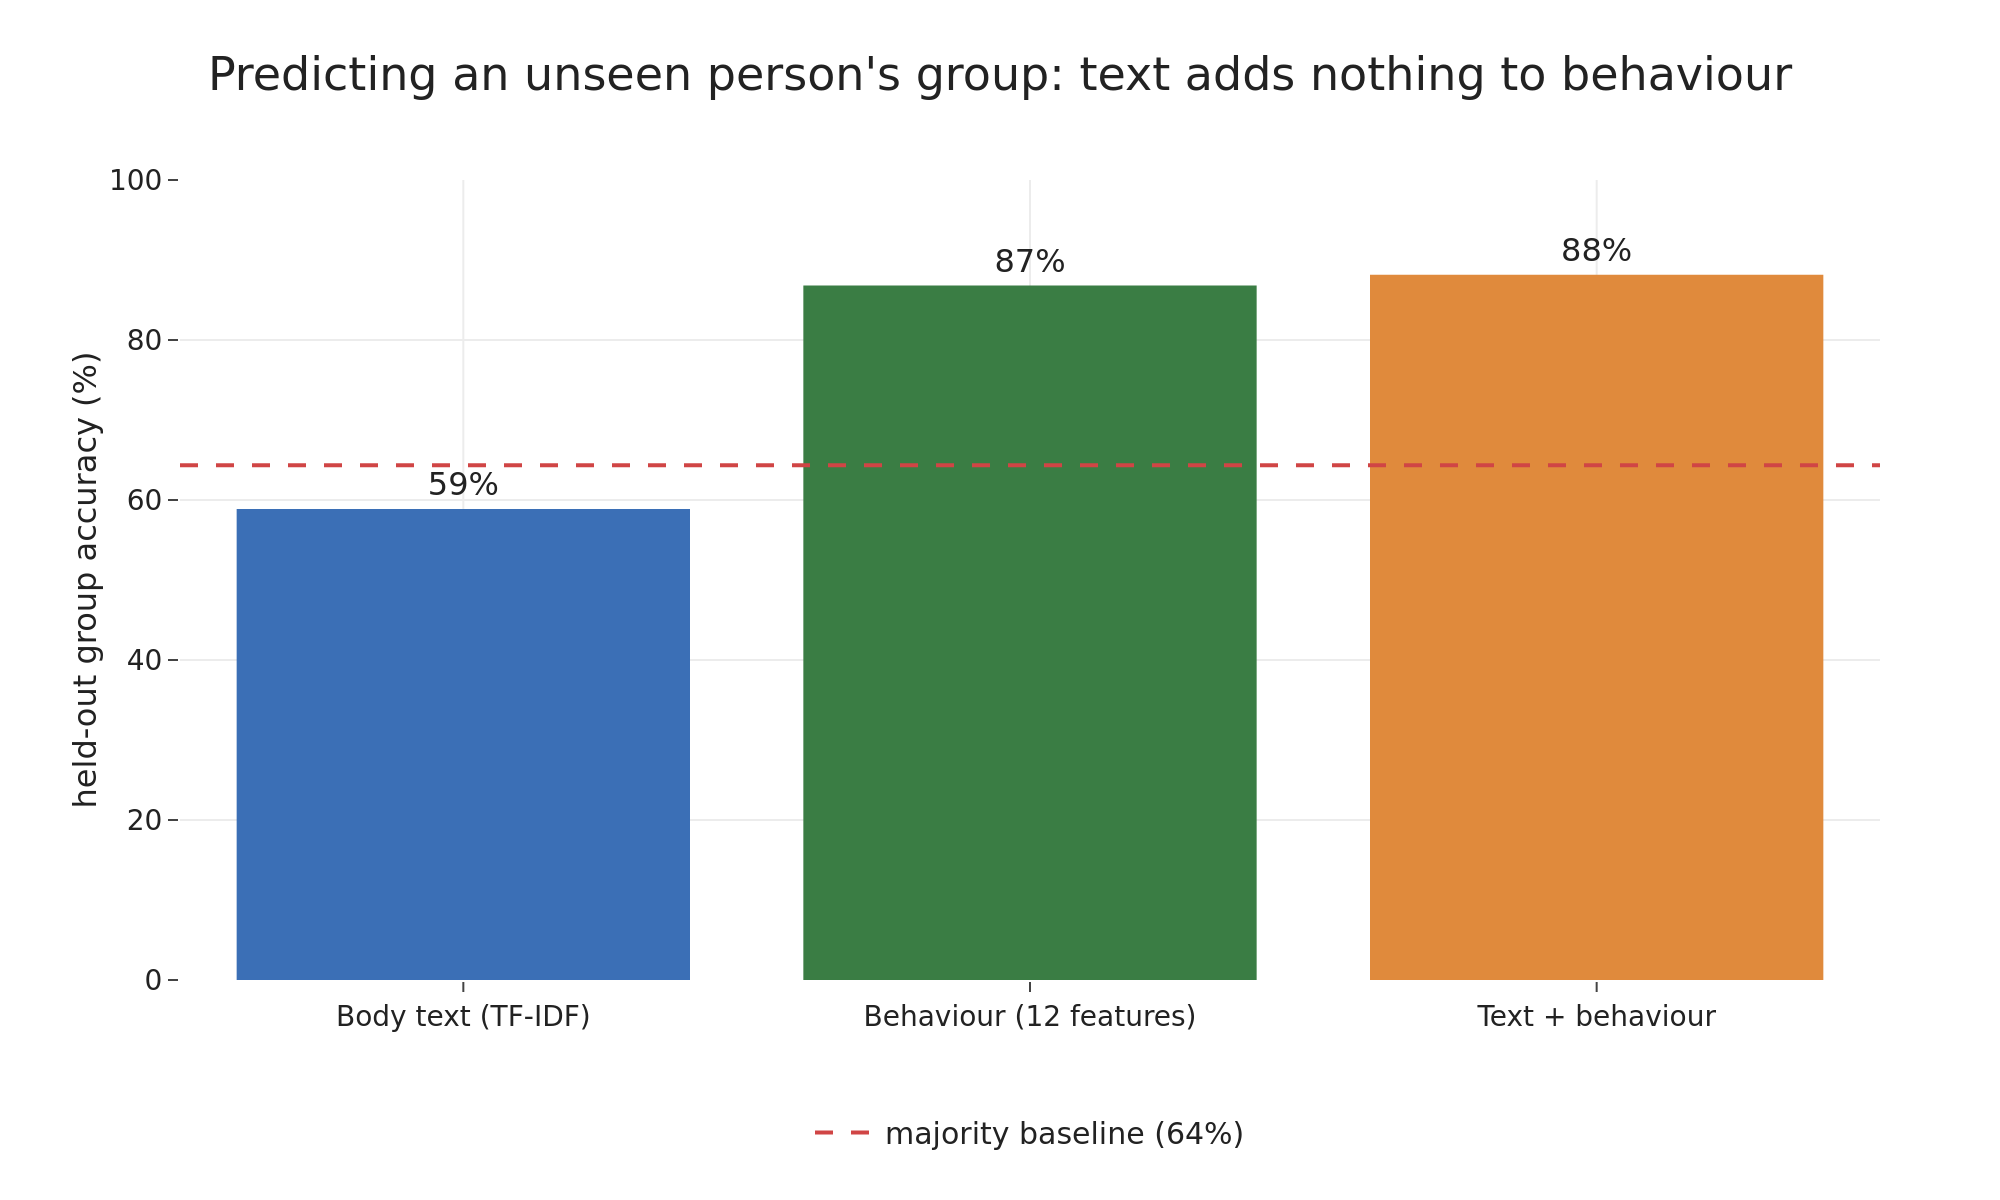

In [8]:
import scipy.sparse as sp
kpos = {h: i for i, h in enumerate(keep)}
Bmsg = X[np.asarray([kpos[p] for p in persons])]      # author's 12 features, per message
FEAT_SETS = {"Body text (TF-IDF)": Xw,
             "Behaviour (12 features)": sp.csr_matrix(Bmsg),
             "Text + behaviour": sp.hstack([Xw, sp.csr_matrix(Bmsg)]).tocsr()}
combo = {}
for name, Xr in FEAT_SETS.items():
    pr = cross_val_predict(LinearSVC(C=1), Xr, ygrp, groups=persons, cv=GroupKFold(5), n_jobs=-1)
    combo[name] = accuracy_score(ygrp, pr)
print({k: round(v, 3) for k, v in combo.items()}, "| majority", round(maj, 3))

order = list(FEAT_SETS)
fig = go.Figure()
fig.add_trace(go.Bar(x=order, y=[combo[k] * 100 for k in order],
    marker_color=[BLUE, GREEN, ORANGE], text=[f"{combo[k]:.0%}" for k in order],
    textposition="outside", showlegend=False))
fig.add_hline(y=maj * 100, line=dict(color=RED, dash="dash"))
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
    line=dict(color=RED, dash="dash", width=2), name=f"majority baseline ({maj:.0%})"))
fig.update_yaxes(title_text="held-out group accuracy (%)", range=[0, 100])
fig.update_layout(title="Predicting an unseen person's group: text adds nothing to behaviour",
    legend=dict(orientation="h", y=-0.15, x=0.5, xanchor="center"))
save_fig(fig, "w6_5_text_plus_behaviour.png", w=1000, h=600,
         margin=dict(l=90, r=60, t=90, b=110))

## Discussion and open ends

The two questions split cleanly. **Who** wrote a message is strongly legible in
the body - three quarters accuracy among ten candidates, well above chance among
fifty - and the signal is robust across raw words, a dense embedding, and pure
character style. **Which behavioural group** an unseen author belongs to is not:
every representation lands at or below the majority baseline once whole people
are held out, and the apparent skill on a random split was the model recognising
individuals and reading their group off by name. The behavioural groups are
defined by communication structure - how many people you reach, how widely you
broadcast - and that structure leaves little trace in the words.

A few caveats carry over. Two executive desks resolve to an assistant's address,
so "wrote" for those mailboxes means "sent from that desk". The per-person cap of
120 messages keeps the corpus balanced but discards volume for the heaviest
senders. And the held-out-people result is the honest ceiling for *this* signal:
a sentence-transformer embedding is the obvious next thing to try, but since a
200-dimension semantic embedding and character-level style both already fail the
group task while succeeding at the individual one, the limit looks like a
property of the signal - topic and idiolect are person-specific, the behavioural
role is not - rather than of the encoder. The open question for predictive mining
is therefore whether the group becomes learnable only when text is combined with
the behavioural features it is actually built from.